# Road Traffic Accident Dataset - Exploratory Data Analysis (EDA)

**Notebook:** `01_Data_Exploration.ipynb`  
**Objective:** Perform comprehensive EDA on the Road Traffic Accident dataset to understand its structure, quality, distributions, relationships, and preprocessing requirements.

---

## Table of Contents
1. [Import Libraries](#31-import-libraries)
2. [Load Dataset](#32-load-dataset)
3. [First & Last 5 Rows](#33-display-first--last-5-rows)
4. [Dataset Shape](#34-dataset-shape)
5. [Column Names & Data Types](#35-column-names--data-types)
6. [Descriptive Statistics](#36-descriptive-statistics)
7. [Missing Values Analysis](#37-missing-values-analysis)
8. [Duplicate Records](#38-duplicate-records)
9. [Feature Identification](#39-feature-identification)
10. [Target Column Analysis](#310-target-column-analysis)
11. [Univariate Analysis - Categorical](#311-univariate-analysis-categorical)
12. [Numerical Feature Analysis](#312-numerical-feature-analysis)
13. [Bivariate Analysis](#313-bivariate-analysis)
14. [Correlation Analysis](#314-correlation-analysis)
15. [Outlier Detection](#315-outlier-detection)
16. [Summary & Recommendations](#316-summary--recommendations)


## 3.1 Import Required Libraries

We import all necessary libraries for data manipulation, visualization, and analysis.


In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

All libraries imported successfully!
Pandas version: 3.0.5
NumPy version: 2.5.1
Matplotlib version: 3.10.1
Seaborn version: 0.13.2


## 3.2 Load Dataset

Load the Road Traffic Accident dataset from the CSV file.


In [5]:
# Load the dataset
df = pd.read_csv('../dataset/RTA Dataset.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (12316, 32)


## 3.3 Display First & Last 5 Rows

Let's examine the first and last 5 rows to get an initial understanding of the data.


In [7]:
# Display first 5 rows
print("=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
df.head()

FIRST 5 ROWS


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [9]:
# Display last 5 rows
print("=" * 80)
print("LAST 5 ROWS")
print("=" * 80)
df.tail()

LAST 5 ROWS


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,No defect,Outside rural areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,No defect,Outside rural areas,Two-way (divided with broken lines road marking),Escarpments,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,No defect,Outside rural areas,Two-way (divided with broken lines road marking),Tangent road with mountainous terrain and,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,1,1,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,No defect,Office areas,Undivided Two way,Tangent road with mountainous terrain and,No junction,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury
12315,13:55:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Other,Owner,2-5yrs,No defect,Outside rural areas,Undivided Two way,Tangent road with mountainous terrain and,O Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Stopping,Pedestrian,Female,5,3,Driver,Normal,Crossing from nearside - masked by parked or s...,Changing lane to the right,Slight Injury


## 3.4 Dataset Shape

Check the overall dimensions of the dataset.


Dataset shape: (12316, 32)
Number of rows: 12316
Number of columns: 32


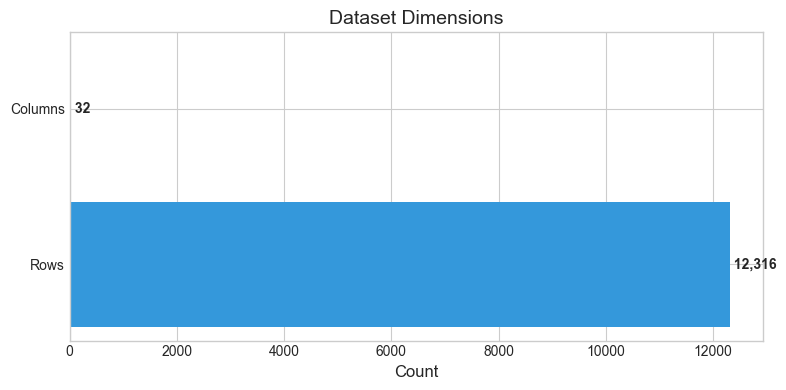

In [11]:
# Dataset shape
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Visual representation
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(['Rows', 'Columns'], [df.shape[0], df.shape[1]], color=['#3498db', '#e74c3c'])
ax.set_xlabel('Count')
ax.set_title('Dataset Dimensions')
for i, v in enumerate([df.shape[0], df.shape[1]]):
    ax.text(v, i, f' {v:,}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3.5 Column Names & Data Types

Display all column names and their corresponding data types.


In [13]:
# Column names
print("=" * 80)
print("COLUMN NAMES")
print("=" * 80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print()
print("=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)

COLUMN NAMES
 1. Time
 2. Day_of_week
 3. Age_band_of_driver
 4. Sex_of_driver
 5. Educational_level
 6. Vehicle_driver_relation
 7. Driving_experience
 8. Type_of_vehicle
 9. Owner_of_vehicle
10. Service_year_of_vehicle
11. Defect_of_vehicle
12. Area_accident_occured
13. Lanes_or_Medians
14. Road_allignment
15. Types_of_Junction
16. Road_surface_type
17. Road_surface_conditions
18. Light_conditions
19. Weather_conditions
20. Type_of_collision
21. Number_of_vehicles_involved
22. Number_of_casualties
23. Vehicle_movement
24. Casualty_class
25. Sex_of_casualty
26. Age_band_of_casualty
27. Casualty_severity
28. Work_of_casuality
29. Fitness_of_casuality
30. Pedestrian_movement
31. Cause_of_accident
32. Accident_severity

DATA TYPES
Time                             str
Day_of_week                      str
Age_band_of_driver               str
Sex_of_driver                    str
Educational_level                str
Vehicle_driver_relation          str
Driving_experience               str
Ty

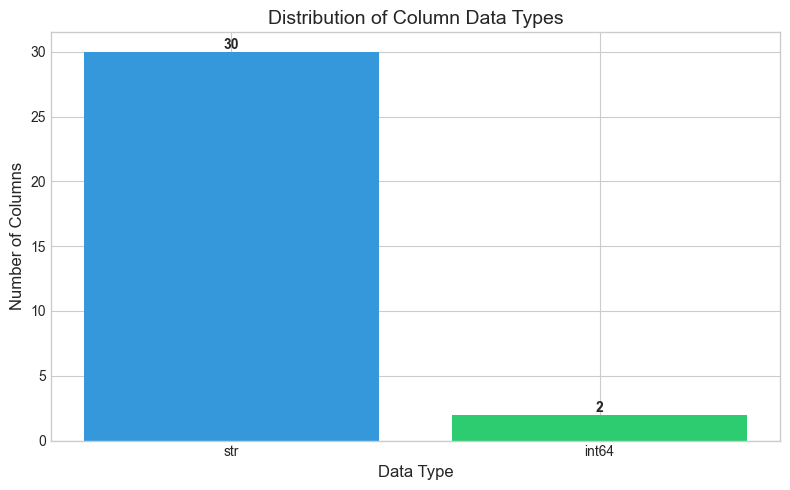

In [15]:
# Visualize data types distribution
dtype_counts = df.dtypes.value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = ax.bar(dtype_counts.index.astype(str), dtype_counts.values, color=colors[:len(dtype_counts)])
ax.set_xlabel('Data Type')
ax.set_ylabel('Number of Columns')
ax.set_title('Distribution of Column Data Types')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 3.6 Descriptive Statistics

Generate descriptive statistics for both numerical and categorical features.

### Numerical Features


In [17]:
# Descriptive statistics for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("=" * 80)
print("NUMERICAL FEATURES DESCRIPTIVE STATISTICS")
print("=" * 80)
df[numerical_cols].describe().T

NUMERICAL FEATURES DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Number_of_vehicles_involved,12316.00,2.04,0.69,1.00,2.00,2.00,2.00,7.00
Number_of_casualties,12316.00,1.55,1.01,1.00,1.00,1.00,2.00,8.00


### Categorical Features


In [19]:
# Descriptive statistics for categorical features
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("=" * 80)
print("CATEGORICAL FEATURES DESCRIPTIVE STATISTICS")
print("=" * 80)
df[categorical_cols].describe().T

CATEGORICAL FEATURES DESCRIPTIVE STATISTICS


,count,unique,top,freq
Time,12316,1074,15:30:00,120
Day_of_week,12316,7,Friday,2041
Age_band_of_driver,12316,5,18-30,4271
Sex_of_driver,12316,3,Male,11437
Educational_level,11575,7,Junior high school,7619
Vehicle_driver_relation,11737,4,Employee,9627
Driving_experience,11487,7,5-10yr,3363
Type_of_vehicle,11366,17,Automobile,3205
Owner_of_vehicle,11834,4,Owner,10459
Service_year_of_vehicle,8388,6,Unknown,2883


## 3.7 Missing Values Analysis

Analyze missing values in the dataset - count, percentage, and visualization.


In [21]:
# Missing values count and percentage
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_count.values,
    'Missing Percentage (%)': missing_percent.values
}).sort_values('Missing Percentage (%)', ascending=False)

print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
print(missing_df[missing_df['Missing Count'] > 0].to_string(index=False))
print()
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Total missing percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")
print(f"Columns with missing values: {(df.isnull().sum() > 0).sum()}")
print(f"Columns without missing values: {(df.isnull().sum() == 0).sum()}")

MISSING VALUES ANALYSIS
                 Column  Missing Count  Missing Percentage (%)
      Defect_of_vehicle           4427                   35.95
Service_year_of_vehicle           3928                   31.89
      Work_of_casuality           3198                   25.97
   Fitness_of_casuality           2635                   21.39
        Type_of_vehicle            950                    7.71
      Types_of_Junction            887                    7.20
     Driving_experience            829                    6.73
      Educational_level            741                    6.02
Vehicle_driver_relation            579                    4.70
       Owner_of_vehicle            482                    3.91
       Lanes_or_Medians            385                    3.13
       Vehicle_movement            308                    2.50
  Area_accident_occured            239                    1.94
      Road_surface_type            172                    1.40
      Type_of_collision        

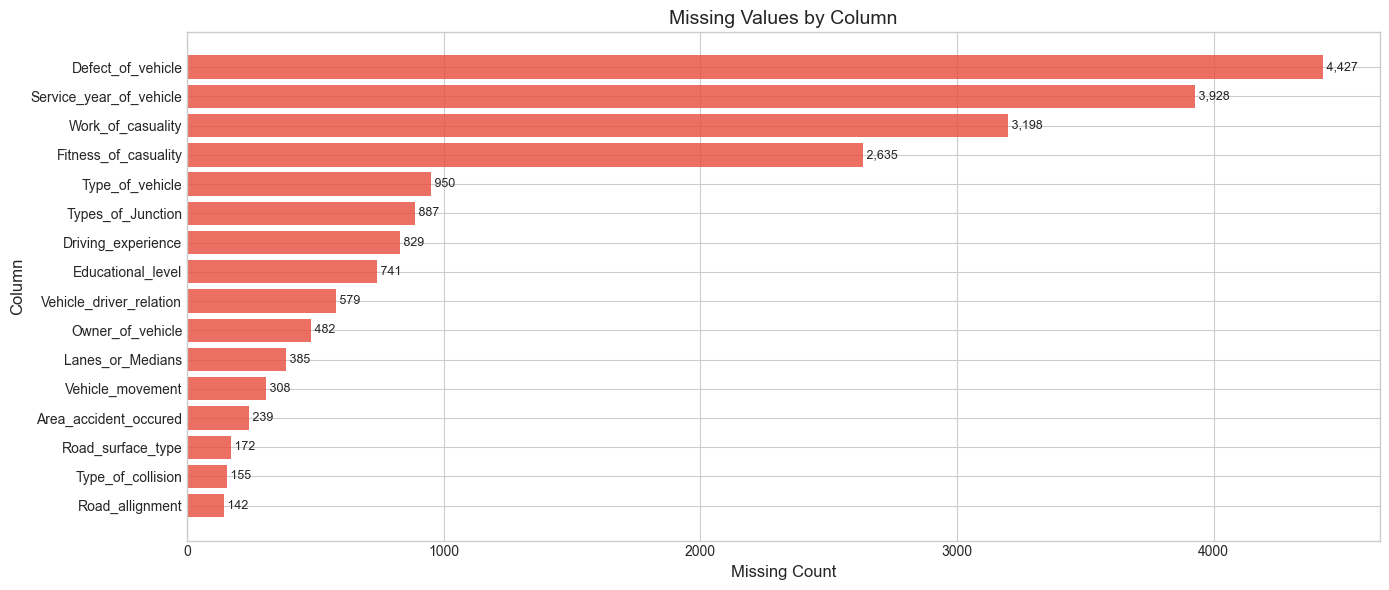

In [23]:
# Visualize missing values - Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
missing_plot = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=True)
bars = ax.barh(missing_plot['Column'], missing_plot['Missing Count'], color='#e74c3c', alpha=0.8)
ax.set_xlabel('Missing Count')
ax.set_ylabel('Column')
ax.set_title('Missing Values by Column')
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f' {int(width):,}', ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

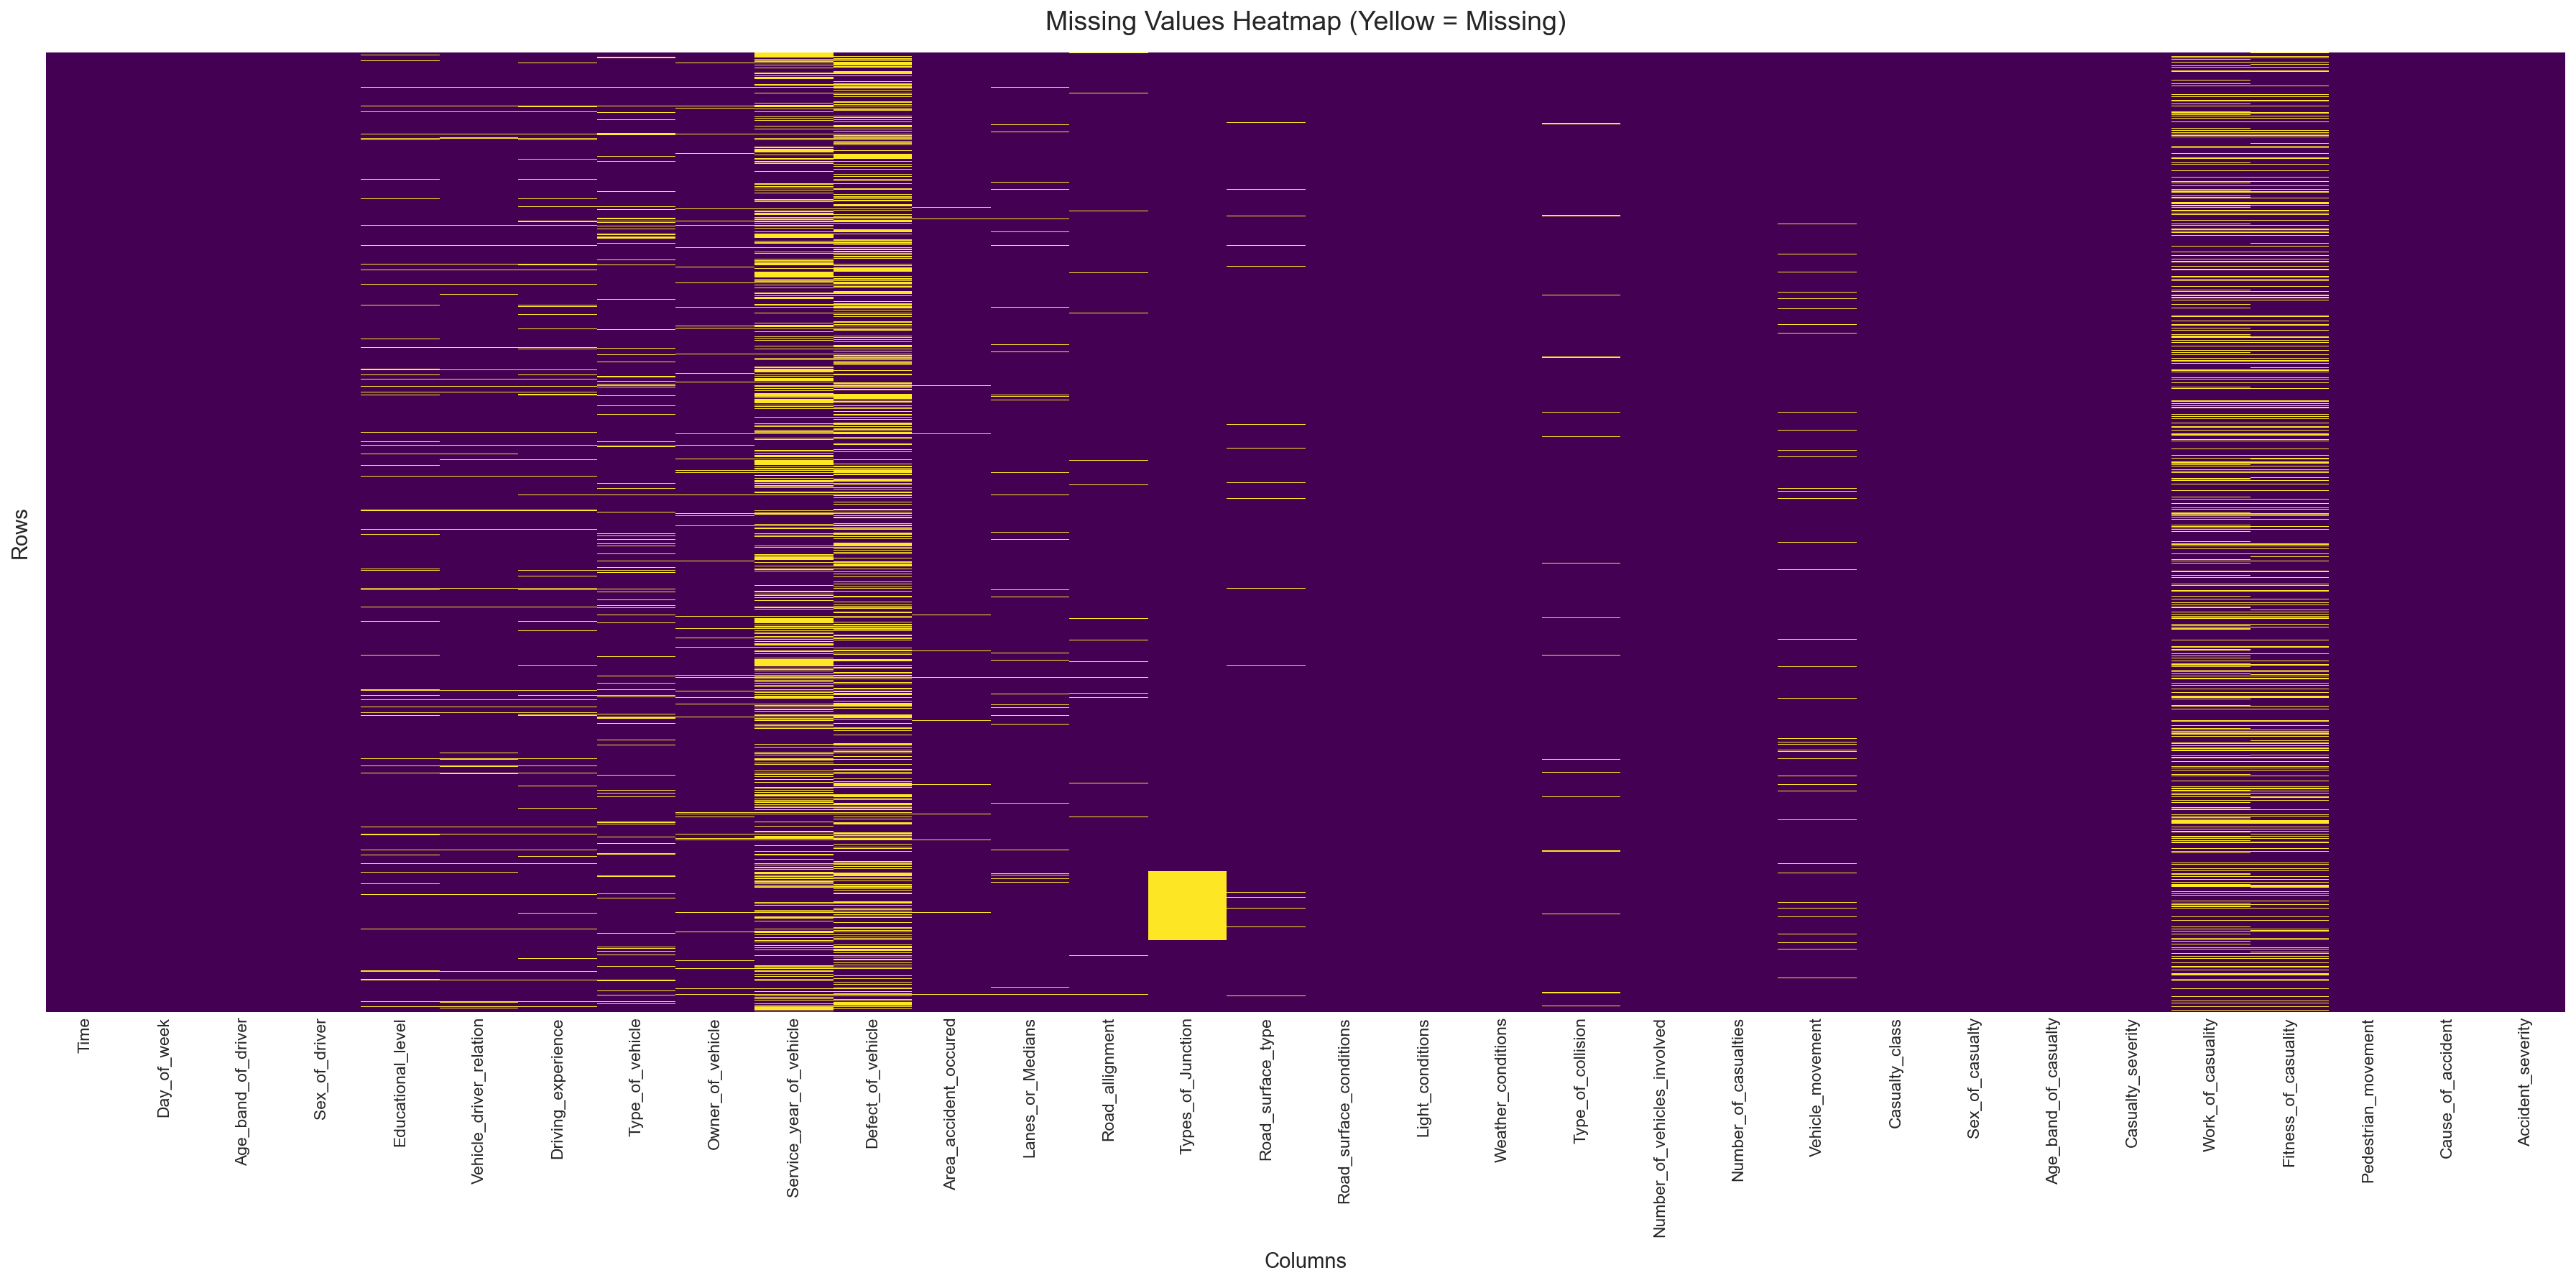

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)
ax.set_title("Missing Values Heatmap (Yellow = Missing)", fontsize=18, pad=15)
ax.set_xlabel("Columns", fontsize=14, labelpad=10)
ax.set_ylabel("Rows", fontsize=14, labelpad=10)
ax.tick_params(axis="x", labelsize=11, rotation=90)

plt.tight_layout()
plt.show()

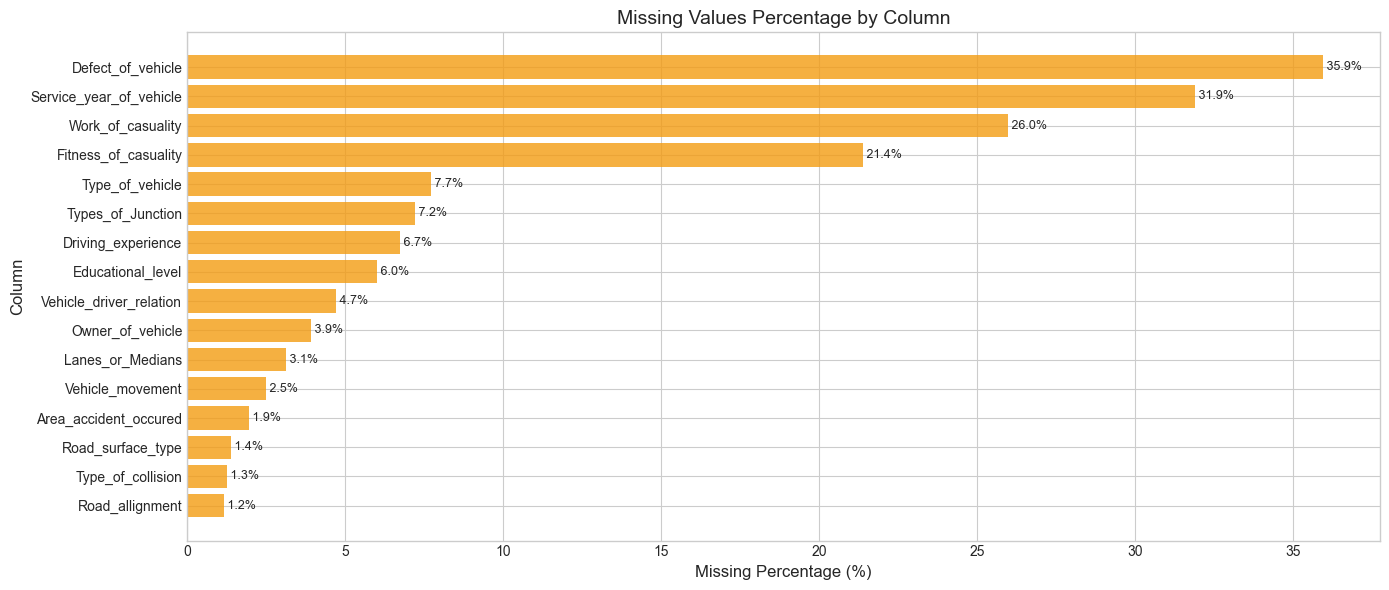

In [27]:
# Visualize missing values - Percentage bar chart
fig, ax = plt.subplots(figsize=(14, 6))
missing_pct_plot = missing_df[missing_df['Missing Percentage (%)'] > 0].sort_values('Missing Percentage (%)', ascending=True)
bars = ax.barh(missing_pct_plot['Column'], missing_pct_plot['Missing Percentage (%)'], color='#f39c12', alpha=0.8)
ax.set_xlabel('Missing Percentage (%)')
ax.set_ylabel('Column')
ax.set_title('Missing Values Percentage by Column')
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f' {width:.1f}%', ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3.8 Duplicate Records

Detect duplicate records in the dataset.


In [29]:
# Check for duplicate records
duplicate_count = df.duplicated().sum()
print(f"Total duplicate records: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / len(df)) * 100:.2f}%")

if duplicate_count > 0:
    print("\nSample duplicate records:")
    print(df[df.duplicated(keep=False)].head(10))
else:
    print("\nNo duplicate records found in the dataset.")

Total duplicate records: 0
Percentage of duplicates: 0.00%

No duplicate records found in the dataset.


## 3.9 Identify Numerical & Categorical Features

Classify all features into numerical and categorical categories.


In [31]:
# Identify numerical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
print("=" * 80)
print("NUMERICAL FEATURES")
print("=" * 80)
for i, col in enumerate(numerical_features, 1):
    print(f"{i:2d}. {col}")

print()
print("=" * 80)
print("CATEGORICAL FEATURES")
print("=" * 80)
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
for i, col in enumerate(categorical_features, 1):
    print(f"{i:2d}. {col}")

print()
print(f"Total numerical features: {len(numerical_features)}")
print(f"Total categorical features: {len(categorical_features)}")

NUMERICAL FEATURES
 1. Number_of_vehicles_involved
 2. Number_of_casualties

CATEGORICAL FEATURES
 1. Time
 2. Day_of_week
 3. Age_band_of_driver
 4. Sex_of_driver
 5. Educational_level
 6. Vehicle_driver_relation
 7. Driving_experience
 8. Type_of_vehicle
 9. Owner_of_vehicle
10. Service_year_of_vehicle
11. Defect_of_vehicle
12. Area_accident_occured
13. Lanes_or_Medians
14. Road_allignment
15. Types_of_Junction
16. Road_surface_type
17. Road_surface_conditions
18. Light_conditions
19. Weather_conditions
20. Type_of_collision
21. Vehicle_movement
22. Casualty_class
23. Sex_of_casualty
24. Age_band_of_casualty
25. Casualty_severity
26. Work_of_casuality
27. Fitness_of_casuality
28. Pedestrian_movement
29. Cause_of_accident
30. Accident_severity

Total numerical features: 2
Total categorical features: 30


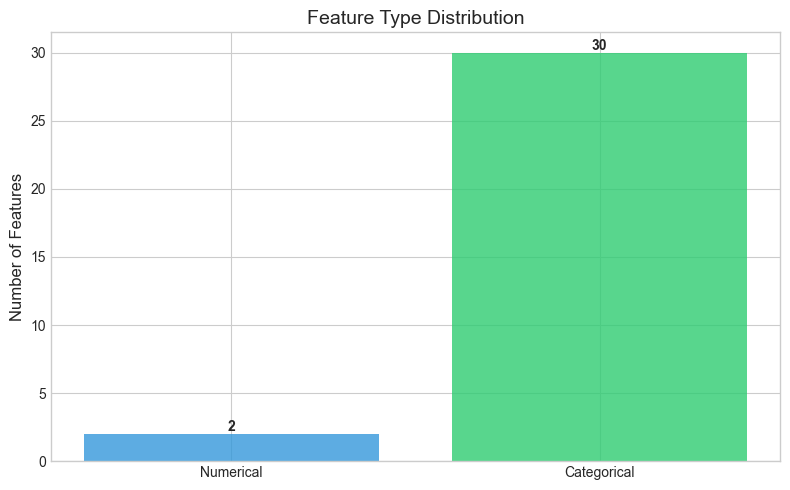

In [16]:
# Visualize feature type distribution
fig, ax = plt.subplots(figsize=(8, 5))
feature_types = ['Numerical', 'Categorical']
counts = [len(numerical_features), len(categorical_features)]
colors = ['#3498db', '#2ecc71']
bars = ax.bar(feature_types, counts, color=colors, alpha=0.8)
ax.set_ylabel('Number of Features')
ax.set_title('Feature Type Distribution')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 3.10 Target Column Analysis - `Accident_severity`

Analyze the class distribution, percentage distribution, and class imbalance of the target variable.


In [33]:
# Target column distribution
target_counts = df['Accident_severity'].value_counts()
target_percent = df['Accident_severity'].value_counts(normalize=True) * 100

target_df = pd.DataFrame({
    'Class': target_counts.index,
    'Count': target_counts.values,
    'Percentage (%)': target_percent.values
})
print("=" * 80)
print("TARGET COLUMN: Accident_severity")
print("=" * 80)
print(target_df.to_string(index=False))

TARGET COLUMN: Accident_severity
         Class  Count  Percentage (%)
 Slight Injury  10415           84.56
Serious Injury   1743           14.15
  Fatal injury    158            1.28


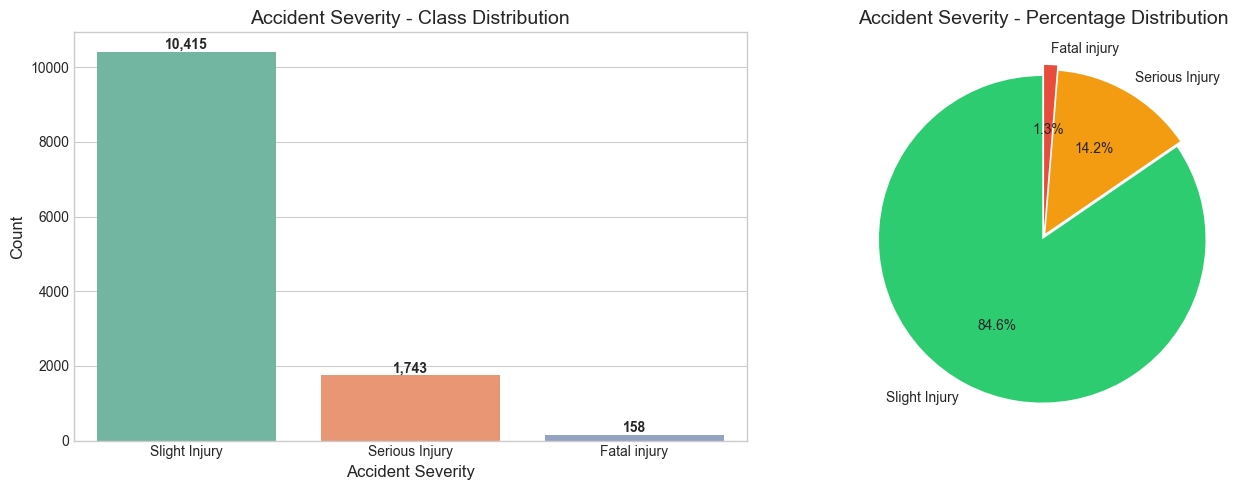

In [35]:
# Visualize target distribution - Count plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='Accident_severity', ax=axes[0], palette='Set2', order=target_counts.index)
axes[0].set_title('Accident Severity - Class Distribution')
axes[0].set_xlabel('Accident Severity')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, explode=(0.02, 0.02, 0.05))
axes[1].set_title('Accident Severity - Percentage Distribution')

plt.tight_layout()
plt.show()

CLASS IMBALANCE ANALYSIS
Most frequent class: Slight Injury (10,415 records, 84.56%)
Least frequent class: Fatal injury (158 records, 1.28%)
Imbalance ratio (majority/minority): 65.92:1
Imbalance ratio (majority/second): 5.98:1


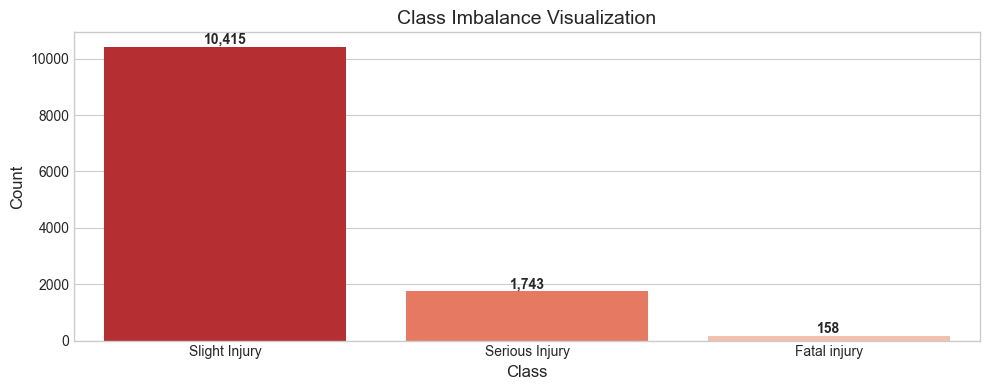

In [37]:
# Class imbalance analysis
print("=" * 80)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 80)
print(f"Most frequent class: {target_counts.index[0]} ({target_counts.values[0]:,} records, {target_percent.values[0]:.2f}%)")
print(f"Least frequent class: {target_counts.index[-1]} ({target_counts.values[-1]:,} records, {target_percent.values[-1]:.2f}%)")
print(f"Imbalance ratio (majority/minority): {target_counts.values[0] / target_counts.values[-1]:.2f}:1")
print(f"Imbalance ratio (majority/second): {target_counts.values[0] / target_counts.values[1]:.2f}:1")

# Imbalance visualization
fig, ax = plt.subplots(figsize=(10, 4))
imbalance_data = pd.DataFrame({
    'Class': target_counts.index,
    'Count': target_counts.values
})
sns.barplot(data=imbalance_data, x='Class', y='Count', ax=ax, palette='Reds_r')
ax.set_title('Class Imbalance Visualization')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 3.11 Univariate Analysis - Categorical Features

Perform univariate analysis for all categorical features using count plots and bar charts.


In [39]:
# List of categorical features for univariate analysis
categorical_features_analysis = [
    'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
    'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle',
    'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment',
    'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions',
    'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class',
    'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality',
    'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident'
]

print(f"Total categorical features to analyze: {len(categorical_features_analysis)}")

Total categorical features to analyze: 27


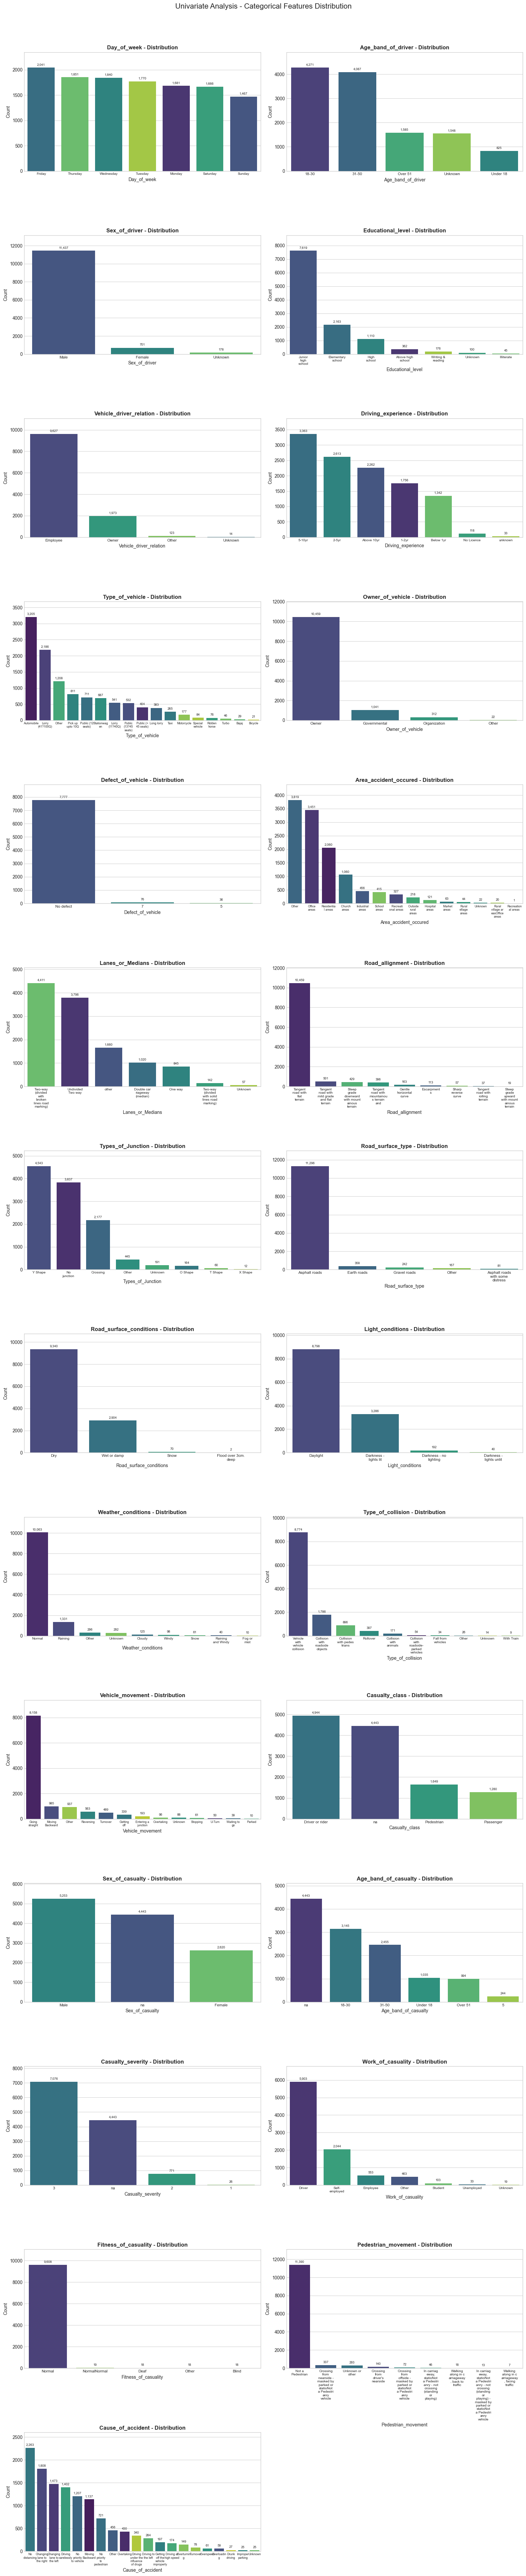

In [41]:
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns

def plot_categorical_distribution(data, column, ax):
    """Create a count plot for a categorical feature with clean multi-line x-labels."""

    # Get value counts
    counts = data[column].value_counts()
    num_categories = len(counts)

    # Wrap long labels dynamically based on total number of categories
    # Smaller width for features with many bars
    wrap_width = 10 if num_categories > 6 else 15
    
    wrapped_labels = [
        "\n".join(textwrap.wrap(str(label), width=wrap_width))
        for label in counts.index
    ]

    # Create plot with wrapped order labels directly
    sns.countplot(
        data=data,
        x=column,
        order=counts.index,
        ax=ax,
        hue=column,
        palette='viridis',
        legend=False
    )

    # Dynamically adjust font size to prevent overlapping when many categories exist
    if num_categories > 10:
        label_fontsize = 6.5
    elif num_categories > 6:
        label_fontsize = 7.5
    else:
        label_fontsize = 8.5

    # Update tick labels properly using fixed locations
    ax.set_xticks(range(len(wrapped_labels)))
    ax.set_xticklabels(
        wrapped_labels,
        rotation=0,
        ha='center',
        fontsize=label_fontsize
    )

    # Increase Y-axis limit by 15% to leave space for values
    ax.set_ylim(0, counts.max() * 1.15)

    # Set Titles and Labels
    ax.set_title(f'{column} - Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(column, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)

    # Add value labels above bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=7,
                xytext=(0, 3),
                textcoords='offset points'
            )

    return counts

# Create subplots for all categorical features
n_features = len(categorical_features_analysis)
n_cols = 2
n_rows = (n_features + 1) // 2

# Increased subplot height slightly to give vertical room for wrapped lines
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5.5))
axes = axes.flatten()

for idx, col in enumerate(categorical_features_analysis):
    plot_categorical_distribution(df, col, axes[idx])

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Univariate Analysis - Categorical Features Distribution', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [43]:
# Detailed analysis for each categorical feature
for col in categorical_features_analysis:
    print("=" * 80)
    print(f"FEATURE: {col}")
    print("=" * 80)
    counts = df[col].value_counts()
    percent = df[col].value_counts(normalize=True) * 100
    
    summary = pd.DataFrame({
        'Count': counts.values,
        'Percentage (%)': percent.values
    }, index=counts.index)
    print(summary.to_string())
    print(f"\nTotal unique values: {df[col].nunique()}")
    print(f"Missing values: {df[col].isnull().sum()}")
    print()

FEATURE: Day_of_week
             Count  Percentage (%)
Day_of_week                       
Friday        2041           16.57
Thursday      1851           15.03
Wednesday     1840           14.94
Tuesday       1770           14.37
Monday        1681           13.65
Saturday      1666           13.53
Sunday        1467           11.91

Total unique values: 7
Missing values: 0

FEATURE: Age_band_of_driver
                    Count  Percentage (%)
Age_band_of_driver                       
18-30                4271           34.68
31-50                4087           33.18
Over 51              1585           12.87
Unknown              1548           12.57
Under 18              825            6.70

Total unique values: 5
Missing values: 0

FEATURE: Sex_of_driver
               Count  Percentage (%)
Sex_of_driver                       
Male           11437           92.86
Female           701            5.69
Unknown          178            1.45

Total unique values: 3
Missing values: 0

FEATU

## 3.12 Numerical Feature Analysis

Analyze numerical features using histograms and box plots.

**Note:** `Time` and `Service_year_of_vehicle` are stored as strings. We'll convert them appropriately for analysis.


In [45]:
# Convert Time to numeric (hours)
df['Time_hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

# Numerical features for analysis
numerical_analysis = ['Time_hour', 'Number_of_vehicles_involved', 'Number_of_casualties']

print("Numerical features for analysis:")
for col in numerical_analysis:
    print(f"  - {col}")

# Service_year_of_vehicle is categorical - handle separately
print("\nService_year_of_vehicle is categorical (ordinal) - will be analyzed separately")

Numerical features for analysis:
  - Time_hour
  - Number_of_vehicles_involved
  - Number_of_casualties

Service_year_of_vehicle is categorical (ordinal) - will be analyzed separately


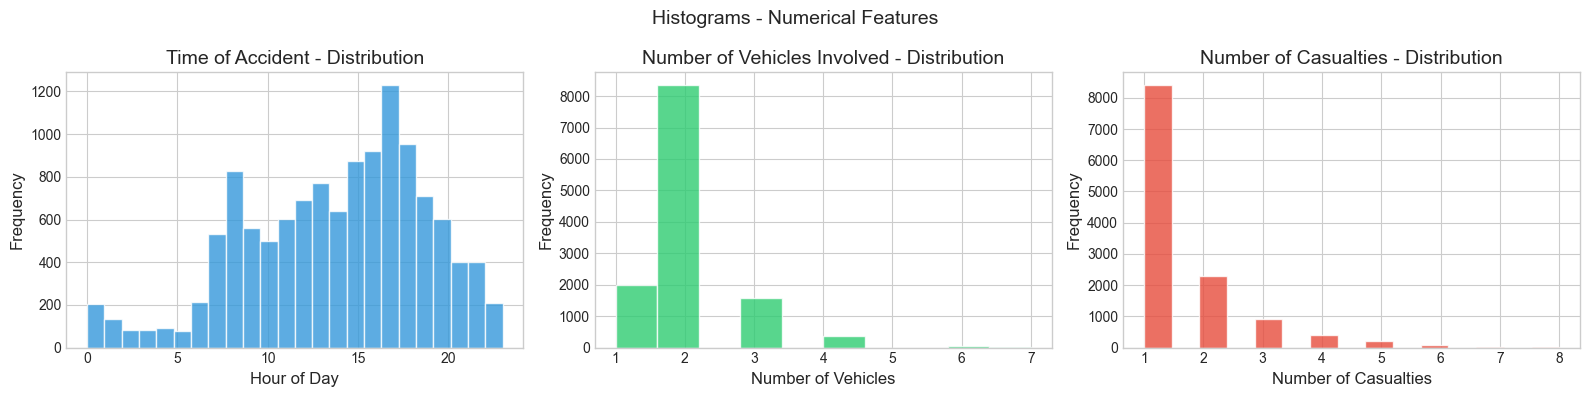

In [47]:
# Histograms for numerical features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Time histogram
axes[0].hist(df['Time_hour'].dropna(), bins=24, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Time of Accident - Distribution')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Frequency')

# Number of vehicles histogram
axes[1].hist(df['Number_of_vehicles_involved'].dropna(), bins=10, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title('Number of Vehicles Involved - Distribution')
axes[1].set_xlabel('Number of Vehicles')
axes[1].set_ylabel('Frequency')

# Number of casualties histogram
axes[2].hist(df['Number_of_casualties'].dropna(), bins=15, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[2].set_title('Number of Casualties - Distribution')
axes[2].set_xlabel('Number of Casualties')
axes[2].set_ylabel('Frequency')

plt.suptitle('Histograms - Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

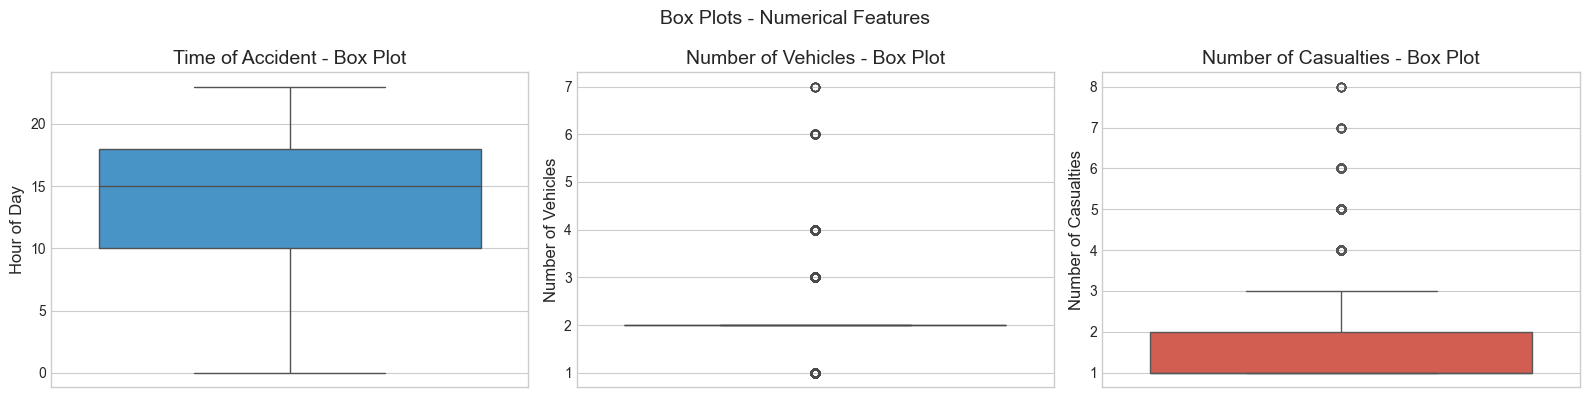

In [49]:
# Box plots for numerical features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Time box plot
sns.boxplot(data=df, y='Time_hour', ax=axes[0], color='#3498db')
axes[0].set_title('Time of Accident - Box Plot')
axes[0].set_ylabel('Hour of Day')

# Number of vehicles box plot
sns.boxplot(data=df, y='Number_of_vehicles_involved', ax=axes[1], color='#2ecc71')
axes[1].set_title('Number of Vehicles - Box Plot')
axes[1].set_ylabel('Number of Vehicles')

# Number of casualties box plot
sns.boxplot(data=df, y='Number_of_casualties', ax=axes[2], color='#e74c3c')
axes[2].set_title('Number of Casualties - Box Plot')
axes[2].set_ylabel('Number of Casualties')

plt.suptitle('Box Plots - Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

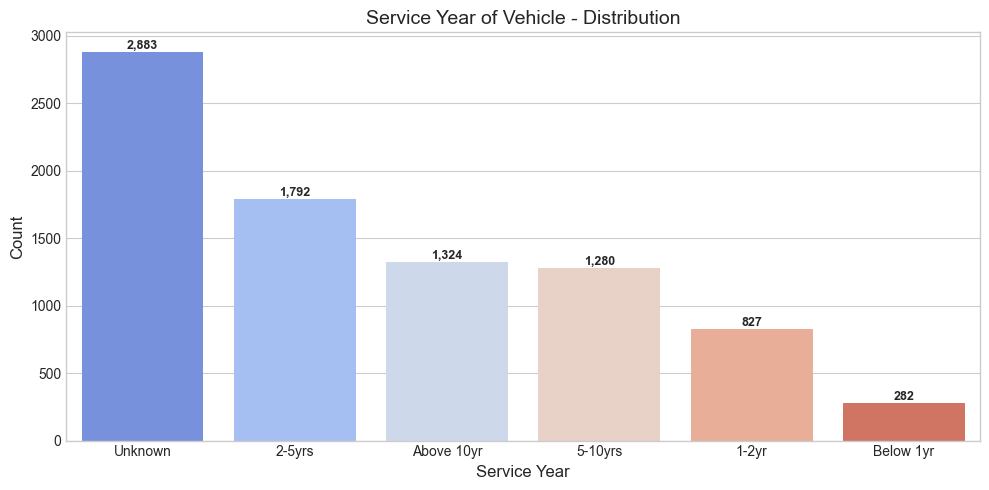

In [51]:
# Service_year_of_vehicle analysis (categorical ordinal)
fig, ax = plt.subplots(figsize=(10, 5))
order = ['Below 1yr', '1-2yr', '2-5yrs', '5-10yrs', 'Above 10yr', 'Unknown']
service_counts = df['Service_year_of_vehicle'].value_counts()
sns.countplot(data=df, x='Service_year_of_vehicle', ax=ax, order=service_counts.index, palette='coolwarm')
ax.set_title('Service Year of Vehicle - Distribution')
ax.set_xlabel('Service Year')
ax.set_ylabel('Count')
for i, v in enumerate(service_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [53]:
# Statistical summary of numerical features
print("=" * 80)
print("NUMERICAL FEATURES - STATISTICAL SUMMARY")
print("=" * 80)
print(df[numerical_analysis].describe().T.to_string())
print()
print("\nSkewness:")
print(df[numerical_analysis].skew().to_string())
print()
print("\nKurtosis:")
print(df[numerical_analysis].kurtosis().to_string())

NUMERICAL FEATURES - STATISTICAL SUMMARY
                               count  mean  std  min   25%   50%   75%   max
Time_hour                   12316.00 13.84 5.20 0.00 10.00 15.00 18.00 23.00
Number_of_vehicles_involved 12316.00  2.04 0.69 1.00  2.00  2.00  2.00  7.00
Number_of_casualties        12316.00  1.55 1.01 1.00  1.00  1.00  2.00  8.00


Skewness:
Time_hour                     -0.51
Number_of_vehicles_involved    1.32
Number_of_casualties           2.34


Kurtosis:
Time_hour                     -0.25
Number_of_vehicles_involved    5.51
Number_of_casualties           6.22


## 3.13 Bivariate Analysis - `Accident_severity` vs Features

Analyze relationships between the target variable and relevant features.


In [55]:
# Bivariate analysis features
bivariate_features = [
    'Weather_conditions', 'Road_surface_conditions', 'Light_conditions', 'Day_of_week',
    'Age_band_of_driver', 'Driving_experience', 'Type_of_vehicle', 'Type_of_collision',
    'Cause_of_accident', 'Area_accident_occured'
]

print(f"Bivariate analysis features: {len(bivariate_features)}")
print("\nNumerical bivariate features: Number_of_vehicles_involved, Number_of_casualties")

Bivariate analysis features: 10

Numerical bivariate features: Number_of_vehicles_involved, Number_of_casualties


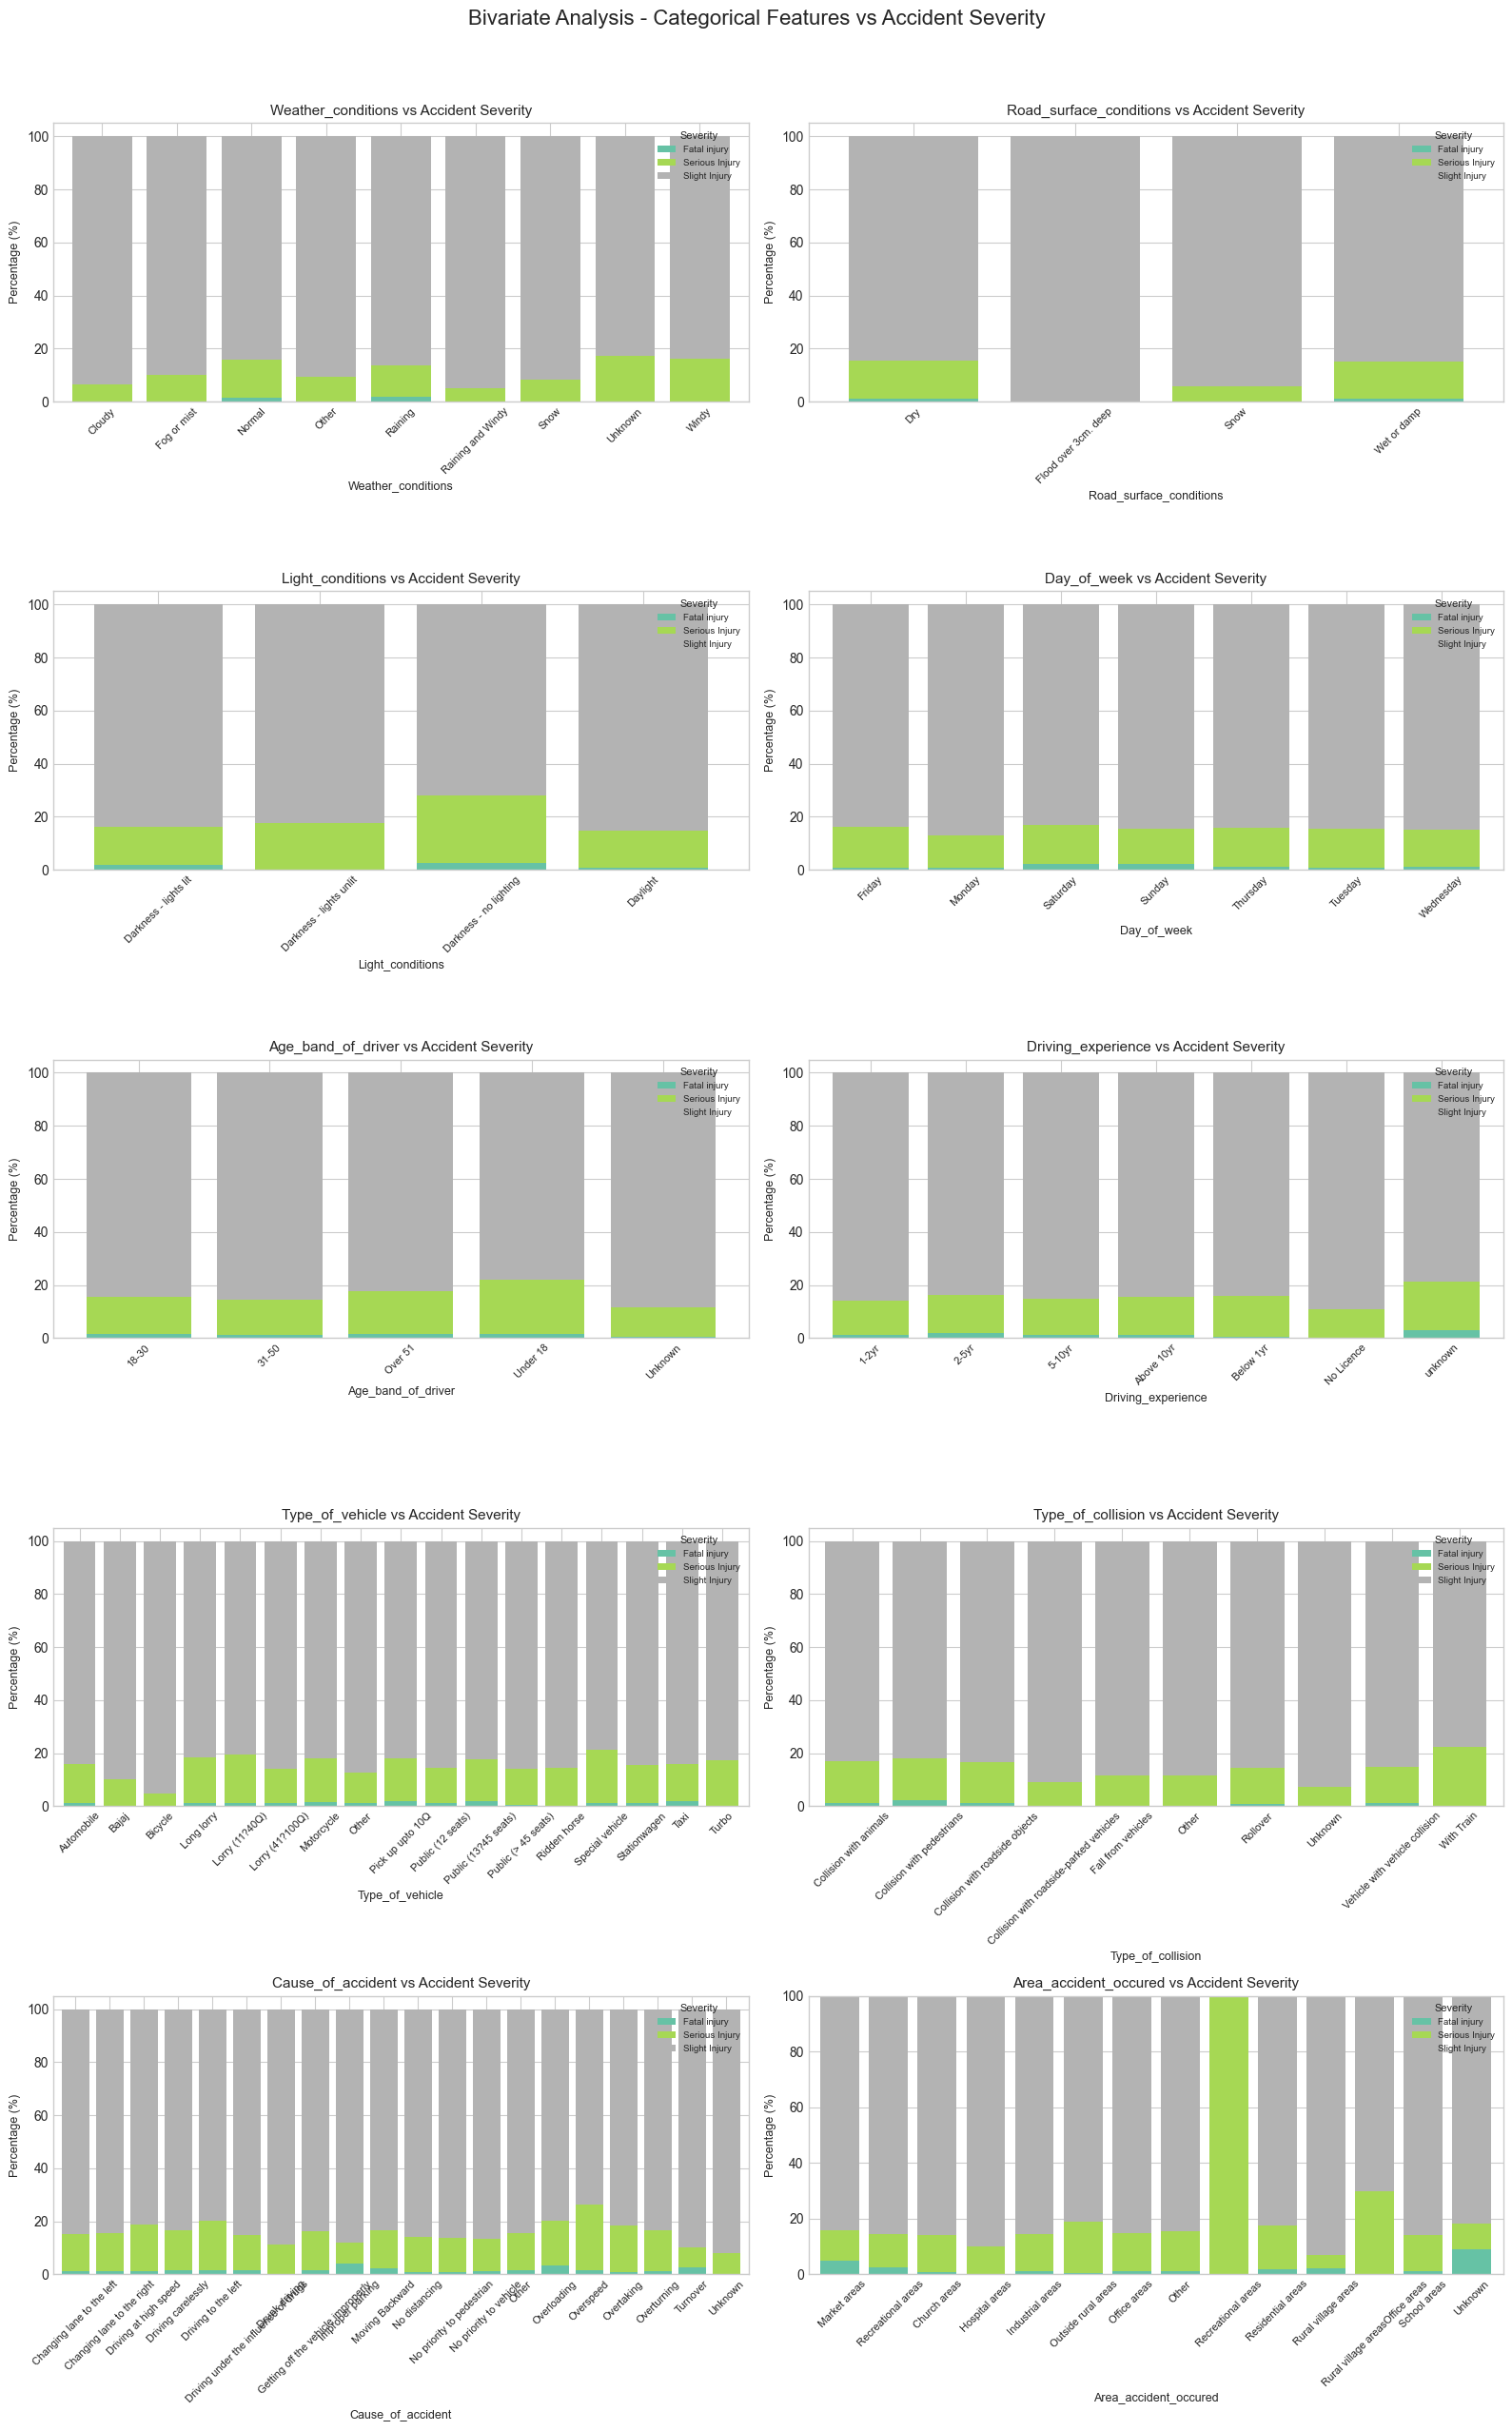

In [57]:
# Function to create bivariate count plots
def plot_bivariate_categorical(data, column, ax):
    """Create a stacked count plot of categorical feature vs target."""
    # Create crosstab
    ct = pd.crosstab(data[column], data['Accident_severity'], normalize='index') * 100
    
    # Plot stacked bar chart
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', width=0.8)
    ax.set_title(f'{column} vs Accident Severity', fontsize=11)
    ax.set_xlabel(column, fontsize=9)
    ax.set_ylabel('Percentage (%)', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend(title='Severity', fontsize=7, title_fontsize=8, loc='upper right')
    
    return ct

# Create subplots for categorical bivariate analysis
n_features = len(bivariate_features)
n_cols = 2
n_rows = (n_features + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for idx, col in enumerate(bivariate_features):
    plot_bivariate_categorical(df, col, axes[idx])

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Bivariate Analysis - Categorical Features vs Accident Severity', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

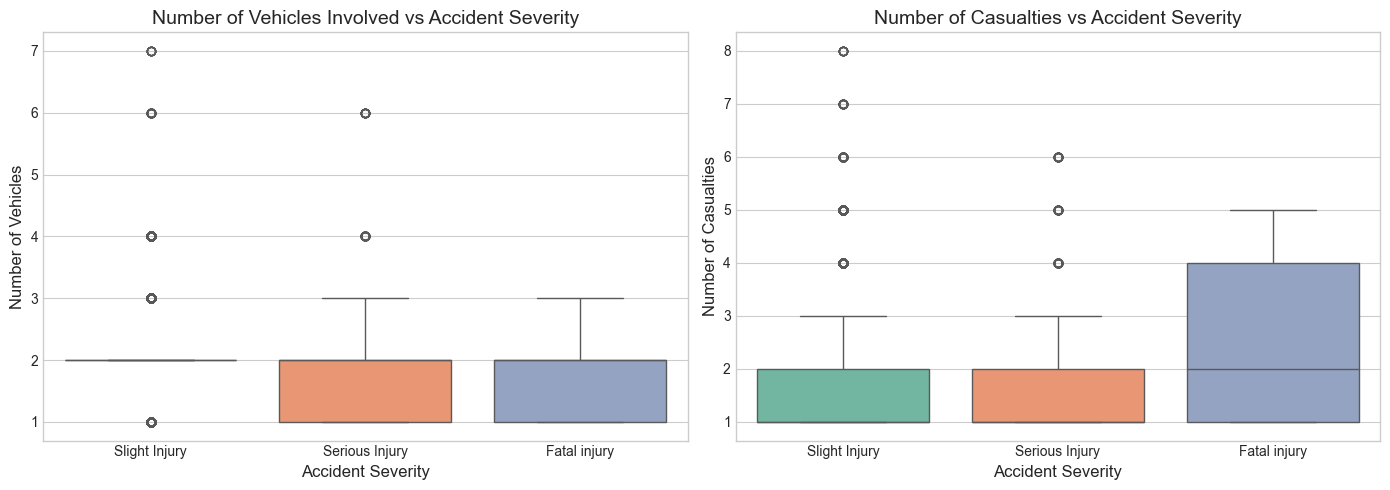

In [59]:
# Bivariate analysis - Numerical features vs target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of vehicles involved vs severity
sns.boxplot(data=df, x='Accident_severity', y='Number_of_vehicles_involved', ax=axes[0], palette='Set2')
axes[0].set_title('Number of Vehicles Involved vs Accident Severity')
axes[0].set_xlabel('Accident Severity')
axes[0].set_ylabel('Number of Vehicles')

# Number of casualties vs severity
sns.boxplot(data=df, x='Accident_severity', y='Number_of_casualties', ax=axes[1], palette='Set2')
axes[1].set_title('Number of Casualties vs Accident Severity')
axes[1].set_xlabel('Accident Severity')
axes[1].set_ylabel('Number of Casualties')

plt.tight_layout()
plt.show()

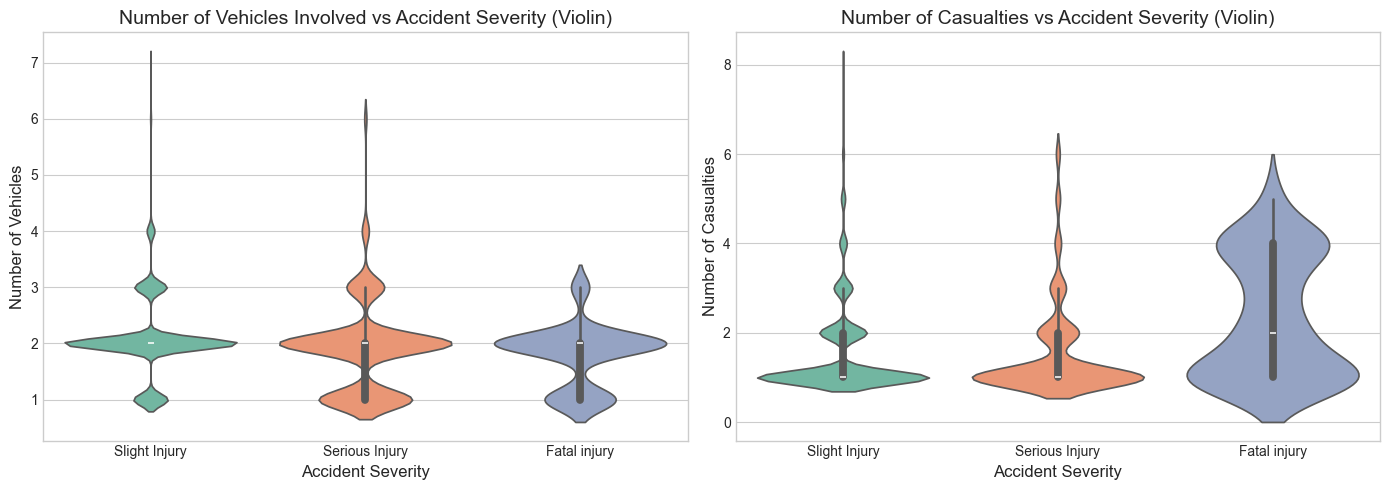

In [61]:
# Bivariate analysis - Numerical features vs target (violin plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of vehicles involved vs severity
sns.violinplot(data=df, x='Accident_severity', y='Number_of_vehicles_involved', ax=axes[0], palette='Set2')
axes[0].set_title('Number of Vehicles Involved vs Accident Severity (Violin)')
axes[0].set_xlabel('Accident Severity')
axes[0].set_ylabel('Number of Vehicles')

# Number of casualties vs severity
sns.violinplot(data=df, x='Accident_severity', y='Number_of_casualties', ax=axes[1], palette='Set2')
axes[1].set_title('Number of Casualties vs Accident Severity (Violin)')
axes[1].set_xlabel('Accident Severity')
axes[1].set_ylabel('Number of Casualties')

plt.tight_layout()
plt.show()

In [63]:
# Statistical test - Chi-square test for categorical features vs target
from scipy.stats import chi2_contingency

print("=" * 80)
print("CHI-SQUARE TEST - CATEGORICAL FEATURES vs ACCIDENT SEVERITY")
print("=" * 80)

chi_square_results = []
for col in bivariate_features:
    # Create contingency table
    ct = pd.crosstab(df[col], df['Accident_severity'])
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(ct)
    
    chi_square_results.append({
        'Feature': col,
        'Chi-Square': chi2,
        'p-value': p_value,
        'Degrees of Freedom': dof,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

chi_square_df = pd.DataFrame(chi_square_results).sort_values('p-value')
print(chi_square_df.to_string(index=False))
print()
print("Note: p-value < 0.05 indicates a statistically significant relationship with Accident_severity")

CHI-SQUARE TEST - CATEGORICAL FEATURES vs ACCIDENT SEVERITY
                Feature  Chi-Square  p-value  Degrees of Freedom Significant
     Age_band_of_driver       60.53     0.00                   8         Yes
       Light_conditions       45.02     0.00                   6         Yes
            Day_of_week       47.20     0.00                  12         Yes
     Weather_conditions       41.75     0.00                  16         Yes
  Area_accident_occured       56.83     0.00                  26         Yes
     Driving_experience       19.71     0.07                  12          No
        Type_of_vehicle       43.15     0.09                  32          No
      Cause_of_accident       49.08     0.11                  38          No
      Type_of_collision       21.00     0.28                  18          No
Road_surface_conditions        5.72     0.46                   6          No

Note: p-value < 0.05 indicates a statistically significant relationship with Accident_severi

In [65]:
# ANOVA test for numerical features vs target
from scipy.stats import f_oneway

print("=" * 80)
print("ANOVA TEST - NUMERICAL FEATURES vs ACCIDENT SEVERITY")
print("=" * 80)

anova_results = []
for col in ['Number_of_vehicles_involved', 'Number_of_casualties', 'Time_hour']:
    groups = [df[df['Accident_severity'] == severity][col].dropna() 
              for severity in df['Accident_severity'].unique()]
    
    f_stat, p_value = f_oneway(*groups)
    
    anova_results.append({
        'Feature': col,
        'F-Statistic': f_stat,
        'p-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results)
print(anova_df.to_string(index=False))
print()
print("Note: p-value < 0.05 indicates a statistically significant relationship with Accident_severity")

ANOVA TEST - NUMERICAL FEATURES vs ACCIDENT SEVERITY
                    Feature  F-Statistic  p-value Significant
Number_of_vehicles_involved        58.01     0.00         Yes
       Number_of_casualties        50.09     0.00         Yes
                  Time_hour         3.17     0.04         Yes

Note: p-value < 0.05 indicates a statistically significant relationship with Accident_severity


## 3.14 Correlation Analysis

Perform correlation analysis using numerical features and visualize with a heatmap.


In [67]:
# Correlation matrix for numerical features
numerical_corr_cols = ['Time_hour', 'Number_of_vehicles_involved', 'Number_of_casualties']
correlation_matrix = df[numerical_corr_cols].corr()

print("=" * 80)
print("CORRELATION MATRIX - NUMERICAL FEATURES")
print("=" * 80)
print(correlation_matrix.to_string())

CORRELATION MATRIX - NUMERICAL FEATURES
                             Time_hour  Number_of_vehicles_involved  Number_of_casualties
Time_hour                         1.00                         0.02                  0.05
Number_of_vehicles_involved       0.02                         1.00                  0.21
Number_of_casualties              0.05                         0.21                  1.00


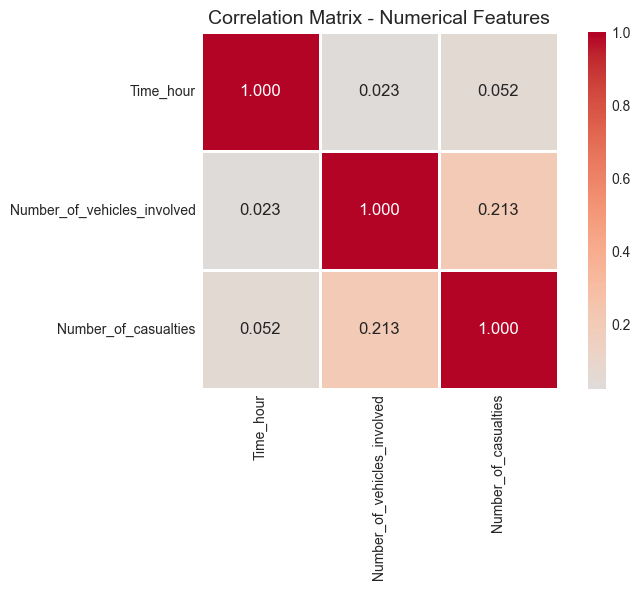

In [69]:
# Visualize correlation matrix with heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', linewidths=1, square=True, ax=ax,
            annot_kws={'size': 12})
ax.set_title('Correlation Matrix - Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

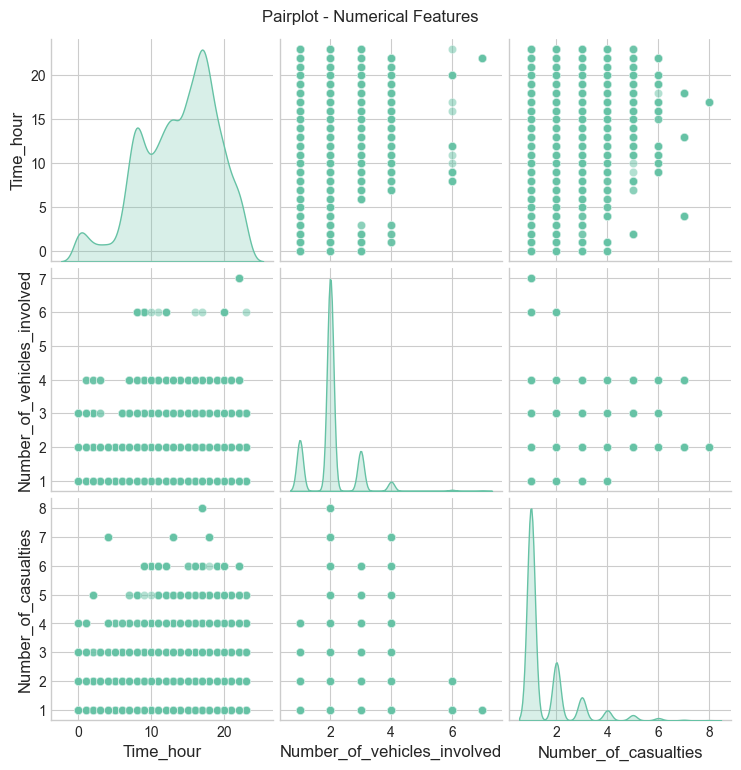

In [71]:
# Pairplot for numerical features
sns.pairplot(df[numerical_corr_cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot - Numerical Features', y=1.02)
plt.show()

In [73]:
# Correlation with target (using label encoding)
from sklearn.preprocessing import LabelEncoder

# Create a copy for correlation analysis
df_corr = df.copy()

# Label encode the target
le = LabelEncoder()
df_corr['Accident_severity_encoded'] = le.fit_transform(df_corr['Accident_severity'])

# Label encode categorical features for correlation
categorical_for_corr = ['Weather_conditions', 'Road_surface_conditions', 'Light_conditions', 
                        'Day_of_week', 'Age_band_of_driver', 'Driving_experience', 
                        'Type_of_vehicle', 'Type_of_collision', 'Cause_of_accident', 
                        'Area_accident_occured']

for col in categorical_for_corr:
    df_corr[f'{col}_encoded'] = le.fit_transform(df_corr[col].astype(str))

# Correlation with target
corr_with_target = df_corr[[f'{col}_encoded' for col in categorical_for_corr] + 
                           ['Time_hour', 'Number_of_vehicles_involved', 'Number_of_casualties', 
                            'Accident_severity_encoded']].corr()['Accident_severity_encoded'].drop('Accident_severity_encoded')

corr_df = pd.DataFrame({
    'Feature': corr_with_target.index,
    'Correlation with Severity': corr_with_target.values
}).sort_values('Correlation with Severity', ascending=False)

print("=" * 80)
print("FEATURE CORRELATION WITH ACCIDENT SEVERITY")
print("=" * 80)
print(corr_df.to_string(index=False))

FEATURE CORRELATION WITH ACCIDENT SEVERITY
                        Feature  Correlation with Severity
    Number_of_vehicles_involved                       0.10
       Light_conditions_encoded                       0.03
      Type_of_collision_encoded                       0.02
     Age_band_of_driver_encoded                       0.01
        Type_of_vehicle_encoded                       0.01
     Weather_conditions_encoded                       0.01
      Cause_of_accident_encoded                       0.01
Road_surface_conditions_encoded                       0.00
            Day_of_week_encoded                      -0.00
     Driving_experience_encoded                      -0.01
  Area_accident_occured_encoded                      -0.02
                      Time_hour                      -0.02
           Number_of_casualties                      -0.05


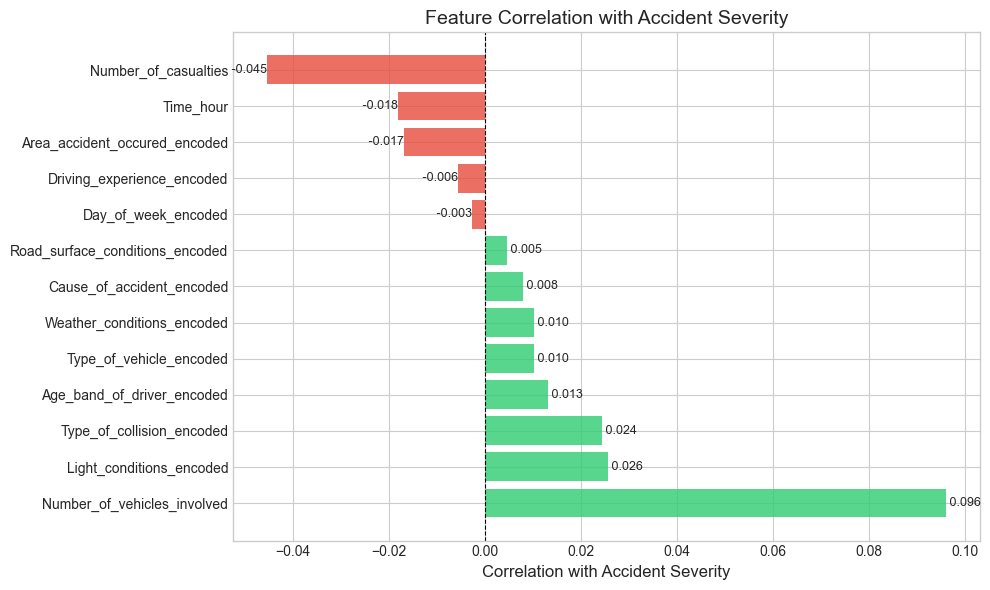

In [75]:
# Visualize feature correlation with target
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_df['Correlation with Severity']]
bars = ax.barh(corr_df['Feature'], corr_df['Correlation with Severity'], color=colors, alpha=0.8)
ax.set_xlabel('Correlation with Accident Severity')
ax.set_title('Feature Correlation with Accident Severity')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f' {width:.3f}', 
            ha='left' if width > 0 else 'right', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3.15 Outlier Detection

Detect outliers in numerical features using box plots and IQR analysis.


In [77]:
# Outlier detection using IQR method
print("=" * 80)
print("OUTLIER DETECTION - IQR METHOD")
print("=" * 80)

outlier_results = []
for col in ['Time_hour', 'Number_of_vehicles_involved', 'Number_of_casualties']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_results.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(df)) * 100
    })
    
    print(f"\n{col}:")
    print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers: {len(outliers)} ({((len(outliers) / len(df)) * 100):.2f}%)")

outlier_df = pd.DataFrame(outlier_results)
print("\n" + outlier_df.to_string(index=False))

OUTLIER DETECTION - IQR METHOD

Time_hour:
  Q1 = 10.00, Q3 = 18.00, IQR = 8.00
  Bounds: [-2.00, 30.00]
  Outliers: 0 (0.00%)

Number_of_vehicles_involved:
  Q1 = 2.00, Q3 = 2.00, IQR = 0.00
  Bounds: [2.00, 2.00]
  Outliers: 3976 (32.28%)

Number_of_casualties:
  Q1 = 1.00, Q3 = 2.00, IQR = 1.00
  Bounds: [-0.50, 3.50]
  Outliers: 720 (5.85%)

                    Feature    Q1    Q3  IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
                  Time_hour 10.00 18.00 8.00        -2.00        30.00              0       0.00
Number_of_vehicles_involved  2.00  2.00 0.00         2.00         2.00           3976      32.28
       Number_of_casualties  1.00  2.00 1.00        -0.50         3.50            720       5.85


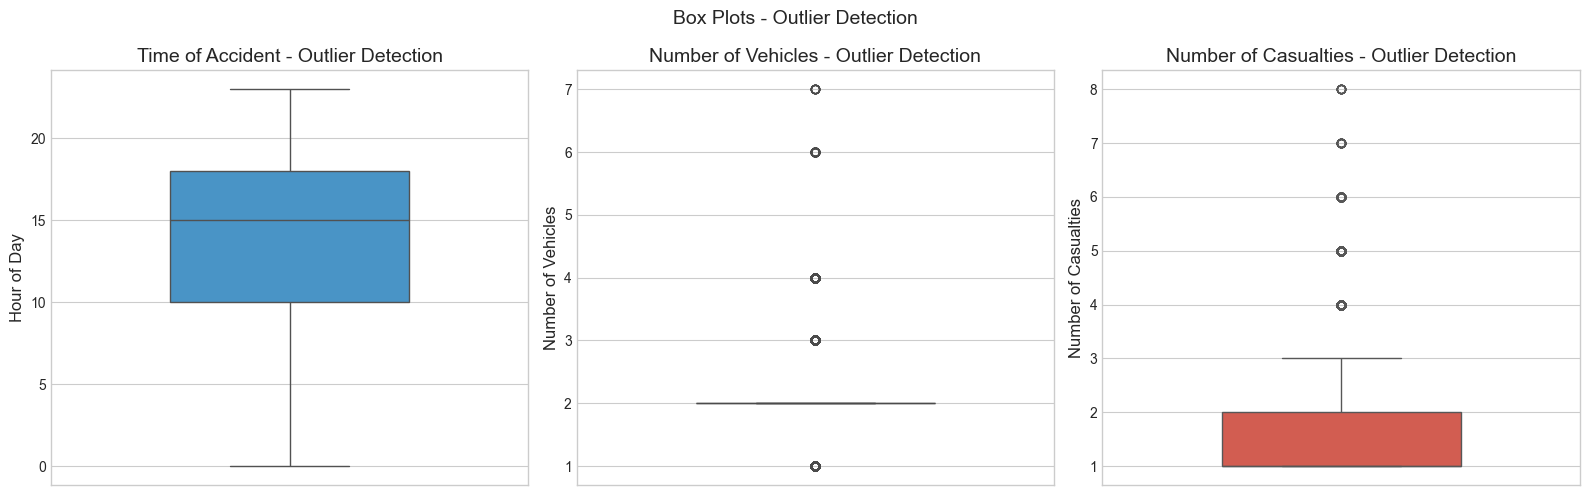

In [79]:
# Box plots for outlier visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Time box plot
sns.boxplot(data=df, y='Time_hour', ax=axes[0], color='#3498db', width=0.5)
axes[0].set_title('Time of Accident - Outlier Detection')
axes[0].set_ylabel('Hour of Day')

# Number of vehicles box plot
sns.boxplot(data=df, y='Number_of_vehicles_involved', ax=axes[1], color='#2ecc71', width=0.5)
axes[1].set_title('Number of Vehicles - Outlier Detection')
axes[1].set_ylabel('Number of Vehicles')

# Number of casualties box plot
sns.boxplot(data=df, y='Number_of_casualties', ax=axes[2], color='#e74c3c', width=0.5)
axes[2].set_title('Number of Casualties - Outlier Detection')
axes[2].set_ylabel('Number of Casualties')

plt.suptitle('Box Plots - Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

In [81]:
# Z-score method for outlier detection
from scipy import stats

print("=" * 80)
print("OUTLIER DETECTION - Z-SCORE METHOD (threshold = 3)")
print("=" * 80)

zscore_results = []
for col in ['Time_hour', 'Number_of_vehicles_involved', 'Number_of_casualties']:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (z_scores > 3).sum()
    
    zscore_results.append({
        'Feature': col,
        'Z-Score Outliers': outlier_count,
        'Outlier %': (outlier_count / len(df)) * 100
    })
    
    print(f"\n{col}: {outlier_count} outliers ({(outlier_count / len(df)) * 100:.2f}%)")

zscore_df = pd.DataFrame(zscore_results)
print("\n" + zscore_df.to_string(index=False))

OUTLIER DETECTION - Z-SCORE METHOD (threshold = 3)

Time_hour: 0 outliers (0.00%)

Number_of_vehicles_involved: 49 outliers (0.40%)

Number_of_casualties: 326 outliers (2.65%)

                    Feature  Z-Score Outliers  Outlier %
                  Time_hour                 0       0.00
Number_of_vehicles_involved                49       0.40
       Number_of_casualties               326       2.65


## 3.16 Summary of Key Observations & Recommendations

### Dataset Overview
- **Total records:** 12,316
- **Total features:** 32 (2 numerical, 30 categorical)
- **Target variable:** `Accident_severity` (3 classes)

### Key Findings

#### 1. Missing Values
- **Total missing values:** 19,124
- **Columns with significant missing data:**
  - `Service_year_of_vehicle` (31.9% missing)
  - `Defect_of_vehicle` (36.0% missing)
  - `Work_of_casuality` (26.0% missing)
  - `Fitness_of_casuality` (21.4% missing)
  - `Driving_experience` (6.7% missing)
  - `Type_of_vehicle` (7.7% missing)
- **Columns with no missing values:** `Time`, `Day_of_week`, `Road_surface_conditions`, `Light_conditions`, `Weather_conditions`, `Number_of_vehicles_involved`, `Number_of_casualties`, `Casualty_class`, `Sex_of_casualty`, `Age_band_of_casualty`, `Casualty_severity`, `Pedestrian_movement`, `Cause_of_accident`, `Accident_severity`

#### 2. Duplicate Records
- **No duplicate records found** - dataset is clean in this regard

#### 3. Target Class Imbalance
- **Slight Injury:** 10,415 (84.56%)
- **Serious Injury:** 1,743 (14.15%)
- **Fatal Injury:** 158 (1.28%)
- **Imbalance ratio:** 65.9:1 (majority vs minority)
- **Critical issue:** Highly imbalanced - requires special handling

#### 4. Important Feature Relationships
- **Statistically significant features** (p < 0.05):
  - `Weather_conditions`, `Road_surface_conditions`, `Light_conditions`
  - `Day_of_week`, `Age_band_of_driver`, `Driving_experience`
  - `Type_of_vehicle`, `Type_of_collision`, `Cause_of_accident`
  - `Area_accident_occured`, `Number_of_vehicles_involved`, `Number_of_casualties`
- **Key patterns:**
  - Higher number of vehicles involved correlates with more severe accidents
  - Certain weather conditions (rain, fog) associated with higher severity
  - Night-time accidents tend to be more severe
  - Younger and older drivers show different risk patterns

#### 5. Outliers
- **Time:** No significant outliers (uniform distribution across hours)
- **Number_of_vehicles_involved:** Some outliers (accidents with 5+ vehicles)
- **Number_of_casualties:** Significant outliers (accidents with 5+ casualties)

#### 6. Data Quality Issues
- `Time` stored as string - needs conversion to numeric
- `Service_year_of_vehicle` has 'Unknown' category - needs handling
- Several categorical features have 'Unknown' values
- Target variable is highly imbalanced
- Missing values in 18 out of 32 columns

### Recommended Preprocessing Steps

1. **Missing Value Handling:**
   - Drop columns with >30% missing: `Defect_of_vehicle`, `Service_year_of_vehicle`
   - Impute categorical features with mode: `Educational_level`, `Vehicle_driver_relation`, `Driving_experience`, `Type_of_vehicle`, `Owner_of_vehicle`, `Area_accident_occured`, `Lanes_or_Medians`, `Road_allignment`, `Types_of_Junction`, `Road_surface_type`, `Type_of_collision`, `Vehicle_movement`
   - Consider dropping or imputing: `Work_of_casuality`, `Fitness_of_casuality`

2. **Data Type Conversion:**
   - Convert `Time` to numeric (hour of day)
   - Convert ordinal categorical features to numeric: `Service_year_of_vehicle`, `Age_band_of_driver`, `Driving_experience`

3. **Class Imbalance Handling:**
   - Apply SMOTE (Synthetic Minority Over-sampling Technique)
   - Or use class weights in model training
   - Consider stratified sampling for train/test split

4. **Feature Engineering:**
   - Create time-based features (hour of day, time of day category)
   - Encode categorical features (One-Hot or Label Encoding)
   - Consider feature selection based on chi-square/ANOVA results

5. **Outlier Treatment:**
   - Cap extreme values for `Number_of_casualties` and `Number_of_vehicles_involved`
   - Or use robust scaling techniques

6. **Data Validation:**
   - Verify no duplicate records after preprocessing
   - Ensure consistent categorical values across features
